<a href="https://colab.research.google.com/github/Wardah1212/Breast_Cancer_Prediction/blob/main/Breast-Cancer-Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# DATASET UPLOAD**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Breast_Cancer.csv to Breast_Cancer.csv


**# LIBRARIES IMPORT**

In [2]:
import pandas as pd
import numpy as np

**#DATASET LOAD**

In [3]:
df = pd.read_csv('Breast_Cancer.csv')

**# DATASET CHECK**

In [4]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [7]:
df.shape

(4024, 16)

**# MISSING CHECK VALUES**

In [8]:
df.isnull().sum()

,0
Age,0
Race,0
Marital Status,0
T Stage,0
N Stage,0
6th Stage,0
differentiate,0
Grade,0
A Stage,0
Tumor Size,0


**# FEATURES OR TARGET SEPARATE**

In [9]:
y = df['Status']

In [10]:
X = df.drop('Status', axis=1)

**# CATEGORICAL DATA CONVERT**

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = le.fit_transform(X[column])

y = le.fit_transform(y)

**# Train Test Split**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**# MODEL TRAIN**

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

**# PREDIICTION**

In [15]:
y_pred = model.predict(X_test)

**# ACCURACY CHECK**

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.915527950310559


**# CONFUSION MATRIX**



In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[672  13]
 [ 55  65]]


**# CLASSIFICATION REPORT**

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       685
           1       0.83      0.54      0.66       120

    accuracy                           0.92       805
   macro avg       0.88      0.76      0.80       805
weighted avg       0.91      0.92      0.91       805



**# VISUALIZATION**

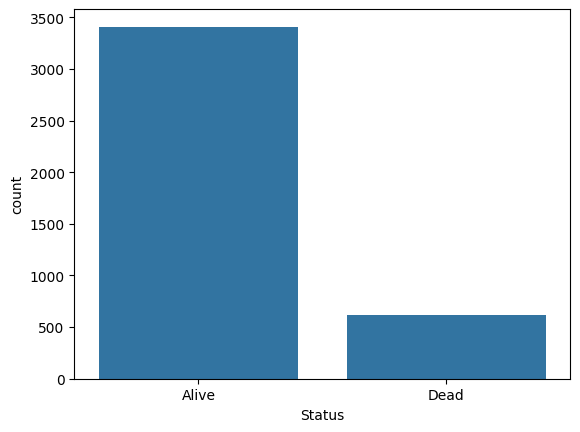

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Status', data=df)
plt.show()

**# FEATURE IMPORTANCE**

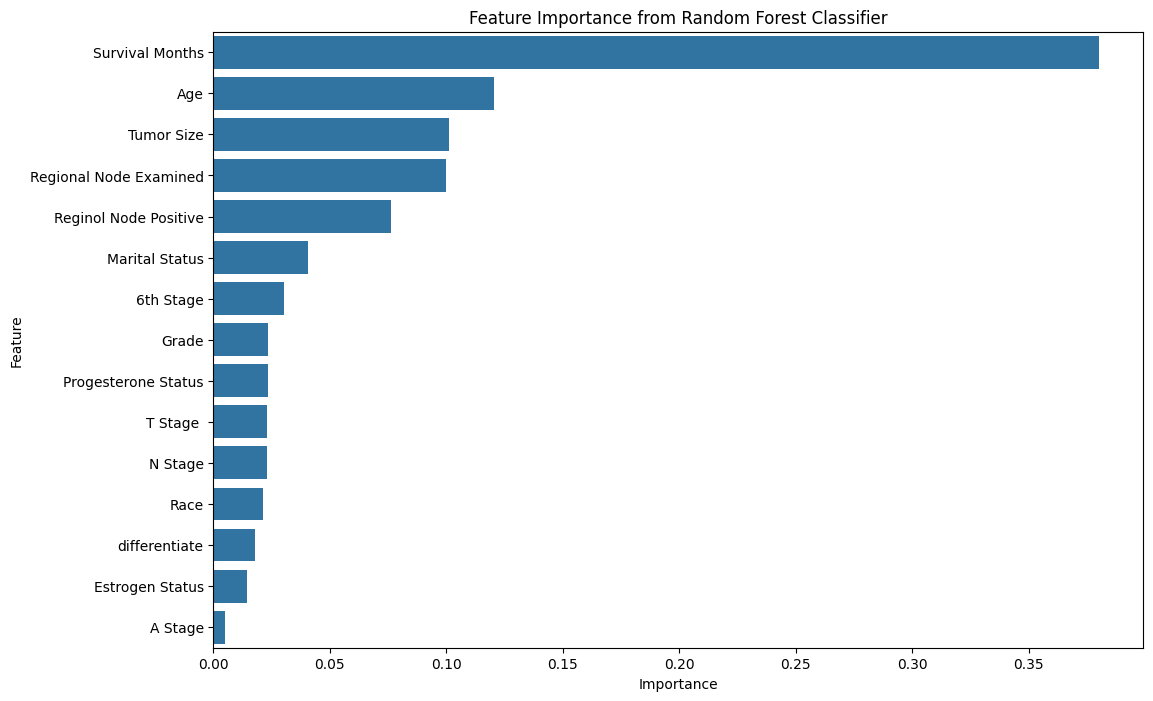

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model
feature_importances = model.feature_importances_

# Get feature names from the training data
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**CONCLUSION:** *In this project, we used Machine Learning algorithms to predict breast cancer survival status. Random Forest classifier gave good accuracy and performance on the dataset."
"The feature importance graph shows that Survival Months and Age were the most influential features in predicting patient survival status.*